# Canonical variable candidate check

Select any of the six canonical variables, inspect candidate coverage, apply its plausible-value rule, and draw time-series and ECDF figures.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlalchemy as sa
from IPython.display import display

HERE = Path.cwd()
OUTPUT_DIR = HERE / 'outfile'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(HERE.parent / 'func'))
from func_variable_mapping import *

DB_URL = os.getenv(
    'CRMP_DB_URL',
    'postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp'
    '?keepalives=1&keepalives_idle=300&keepalives_interval=300'
    '&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass',
)
engine = sa.create_engine(DB_URL, pool_pre_ping=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Parameters

Change `CANONICAL_VARIABLE` to any value shown in `CANONICAL_VARIABLES`. Use `STATION_OFFSET=0` for the first group, `5` for the next group, and so on.

In [2]:
# Change only these two values when reviewing the next variable.
CANONICAL_VARIABLE = 'snowfall_amount'
FINAL_SOURCE_IDS = []  # Fill this after reviewing the plots.
PLOT_VARIABLE_IDS = None  # For example: [434, 721]; None plots all candidates.
NETWORK_ID = 19
STATION_LIMIT = 5
STATION_OFFSET = 20
FIGURE_DIR = HERE / 'variable_mapping_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print('Current variable:', CANONICAL_VARIABLE, sep='\n* ')

print('-----' * 5)
print('Available variables:')
print(*CANONICAL_VARIABLES, sep='\n')

if CANONICAL_VARIABLE not in CANONICAL_VARIABLES:
    raise ValueError(f'Choose one of: {CANONICAL_VARIABLES}')

Current variable:
* snowfall_amount
-------------------------
Available variables:
air_temperature
daily_min_temperature
daily_max_temperature
precipitation_amount
snowfall_amount
snow_depth


## 2. Select stations and load data

In [3]:
# Load the persistent registry directly from CSV.
REGISTRY_PATH = OUTPUT_DIR / '0.net19_candidate_mappings.csv'
all_candidate_mappings = pd.read_csv(REGISTRY_PATH)
candidate_mappings = all_candidate_mappings[
    all_candidate_mappings['network_id'] == NETWORK_ID
].copy()
if candidate_mappings.empty:
    raise ValueError(
        f'No saved mappings for network {NETWORK_ID} in {REGISTRY_PATH}')

candidate_rows = candidate_mappings[
    candidate_mappings['canonical_variable'] == CANONICAL_VARIABLE
]
if candidate_rows.empty:
    raise ValueError(
        f'No {CANONICAL_VARIABLE} candidates saved for network {NETWORK_ID}'
    )
registry_candidate_ids = candidate_rows['vars_id'].astype(int).tolist()

# Use a lightweight existence check for each candidate. A full-network
# profile is expensive for high-volume variables such as air temperature.
representative_station_frames = []
observed_candidate_ids = []
unobserved_candidate_ids = []
for candidate_id in registry_candidate_ids:
    candidate_station = select_candidate_stations(
        engine, [candidate_id], network_id=NETWORK_ID,
        limit=1, offset=0,
    )
    if candidate_station.empty:
        unobserved_candidate_ids.append(candidate_id)
    else:
        observed_candidate_ids.append(candidate_id)
        representative_station_frames.append(candidate_station)

if unobserved_candidate_ids:
    print(
        'Ignoring candidate variables with no network observations:',
        unobserved_candidate_ids,
    )

candidate_rows = candidate_rows[
    candidate_rows['vars_id'].isin(observed_candidate_ids)
].copy()
candidate_ids = candidate_rows['vars_id'].astype(int).tolist()
if not candidate_ids:
    raise ValueError(
        f'None of the saved {CANONICAL_VARIABLE} candidates has '
        f'observations in network {NETWORK_ID}.'
    )
display(candidate_rows)

comparison_stations = select_candidate_stations(
    engine, candidate_ids, network_id=NETWORK_ID,
    limit=STATION_LIMIT, offset=STATION_OFFSET
)

if comparison_stations.empty:
    print(
        'No station contains every observed candidate; selecting the '
        'best-covered station for each candidate instead.'
    )
    comparison_stations = (
        pd.concat(representative_station_frames, ignore_index=True)
        [['station_id', 'station_name']]
        .drop_duplicates(subset='station_id')
        .sort_values('station_id')
        .reset_index(drop=True)
    )

comparison_station_ids = comparison_stations['station_id'].tolist()
display(comparison_stations)

candidate_profile = profile_candidate_variables(
    engine, candidate_ids, network_id=NETWORK_ID,
    station_ids=comparison_station_ids
)
candidate_summary = summarize_candidate_profiles(candidate_profile)
display(candidate_summary.round(2))
display(candidate_profile)

,network_id,vars_id,net_var_name,canonical_variable,daily_aggregation,priority,source_family,mapping_status
6,19,548,snow_amount,snowfall_amount,sum,1,network19_auto,needs_review


,station_id,station_name
0,6630,Port Hardy Airport
1,6631,Port Mellon
2,6632,Powell River
3,6633,Powell River Airport
4,6636,Princeton


/tmp/ipykernel_82737/409892478.py:79: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(candidate_summary.round(2))


,vars_id,net_var_name,station_count,first_observation,last_observation,median_station_span_years,median_active_years
0,548,snow_amount,5,2011-05-31 06:00:00,2013-12-10 23:00:00,1.91,3.0


,station_id,station_name,vars_id,net_var_name,active_years,coverage_years,first_observation,last_observation,observed_min,observed_max
0,6630,Port Hardy Airport,548,snow_amount,3,2.041638,2011-05-31 06:00:00,2013-06-13 23:00:00,0.0,9.5
1,6631,Port Mellon,548,snow_amount,3,1.800707,2011-12-09 06:00:00,2013-09-25 23:00:00,1.0,5.0
2,6632,Powell River,548,snow_amount,2,1.910221,2012-01-14 06:00:00,2013-12-10 23:00:00,1.0,1.0
3,6633,Powell River Airport,548,snow_amount,2,1.094342,2012-11-07 06:00:00,2013-12-10 23:00:00,1.0,20.0
4,6636,Princeton,548,snow_amount,3,2.027949,2011-11-26 06:00:00,2013-12-04 23:00:00,1.0,15.0


## 3. Apply the canonical plausible-value rule

In [4]:
observations = fetch_candidate_observations(
    engine, candidate_ids, comparison_station_ids
)
clean_data, qc_summary = apply_canonical_rule(
    observations, CANONICAL_VARIABLE
)
display(qc_summary.round(2))

,station_id,net_var_name,row_count,removed_count,removed_pct
0,6630,snow_amount,677,0,0.0
1,6631,snow_amount,15,0,0.0
2,6632,snow_amount,5,0,0.0
3,6633,snow_amount,27,0,0.0
4,6636,snow_amount,58,0,0.0


## 4. Time series

In [5]:
# PLOT_VARIABLE_IDS = [442, 726]  # For example: [434, 721]; None plots all candidates.

Saved: /workspaces/crmprtd/Quanlity_Control/pipeline/network_19/variable_mapping_figures/network_19_snowfall_amount_time_series.png


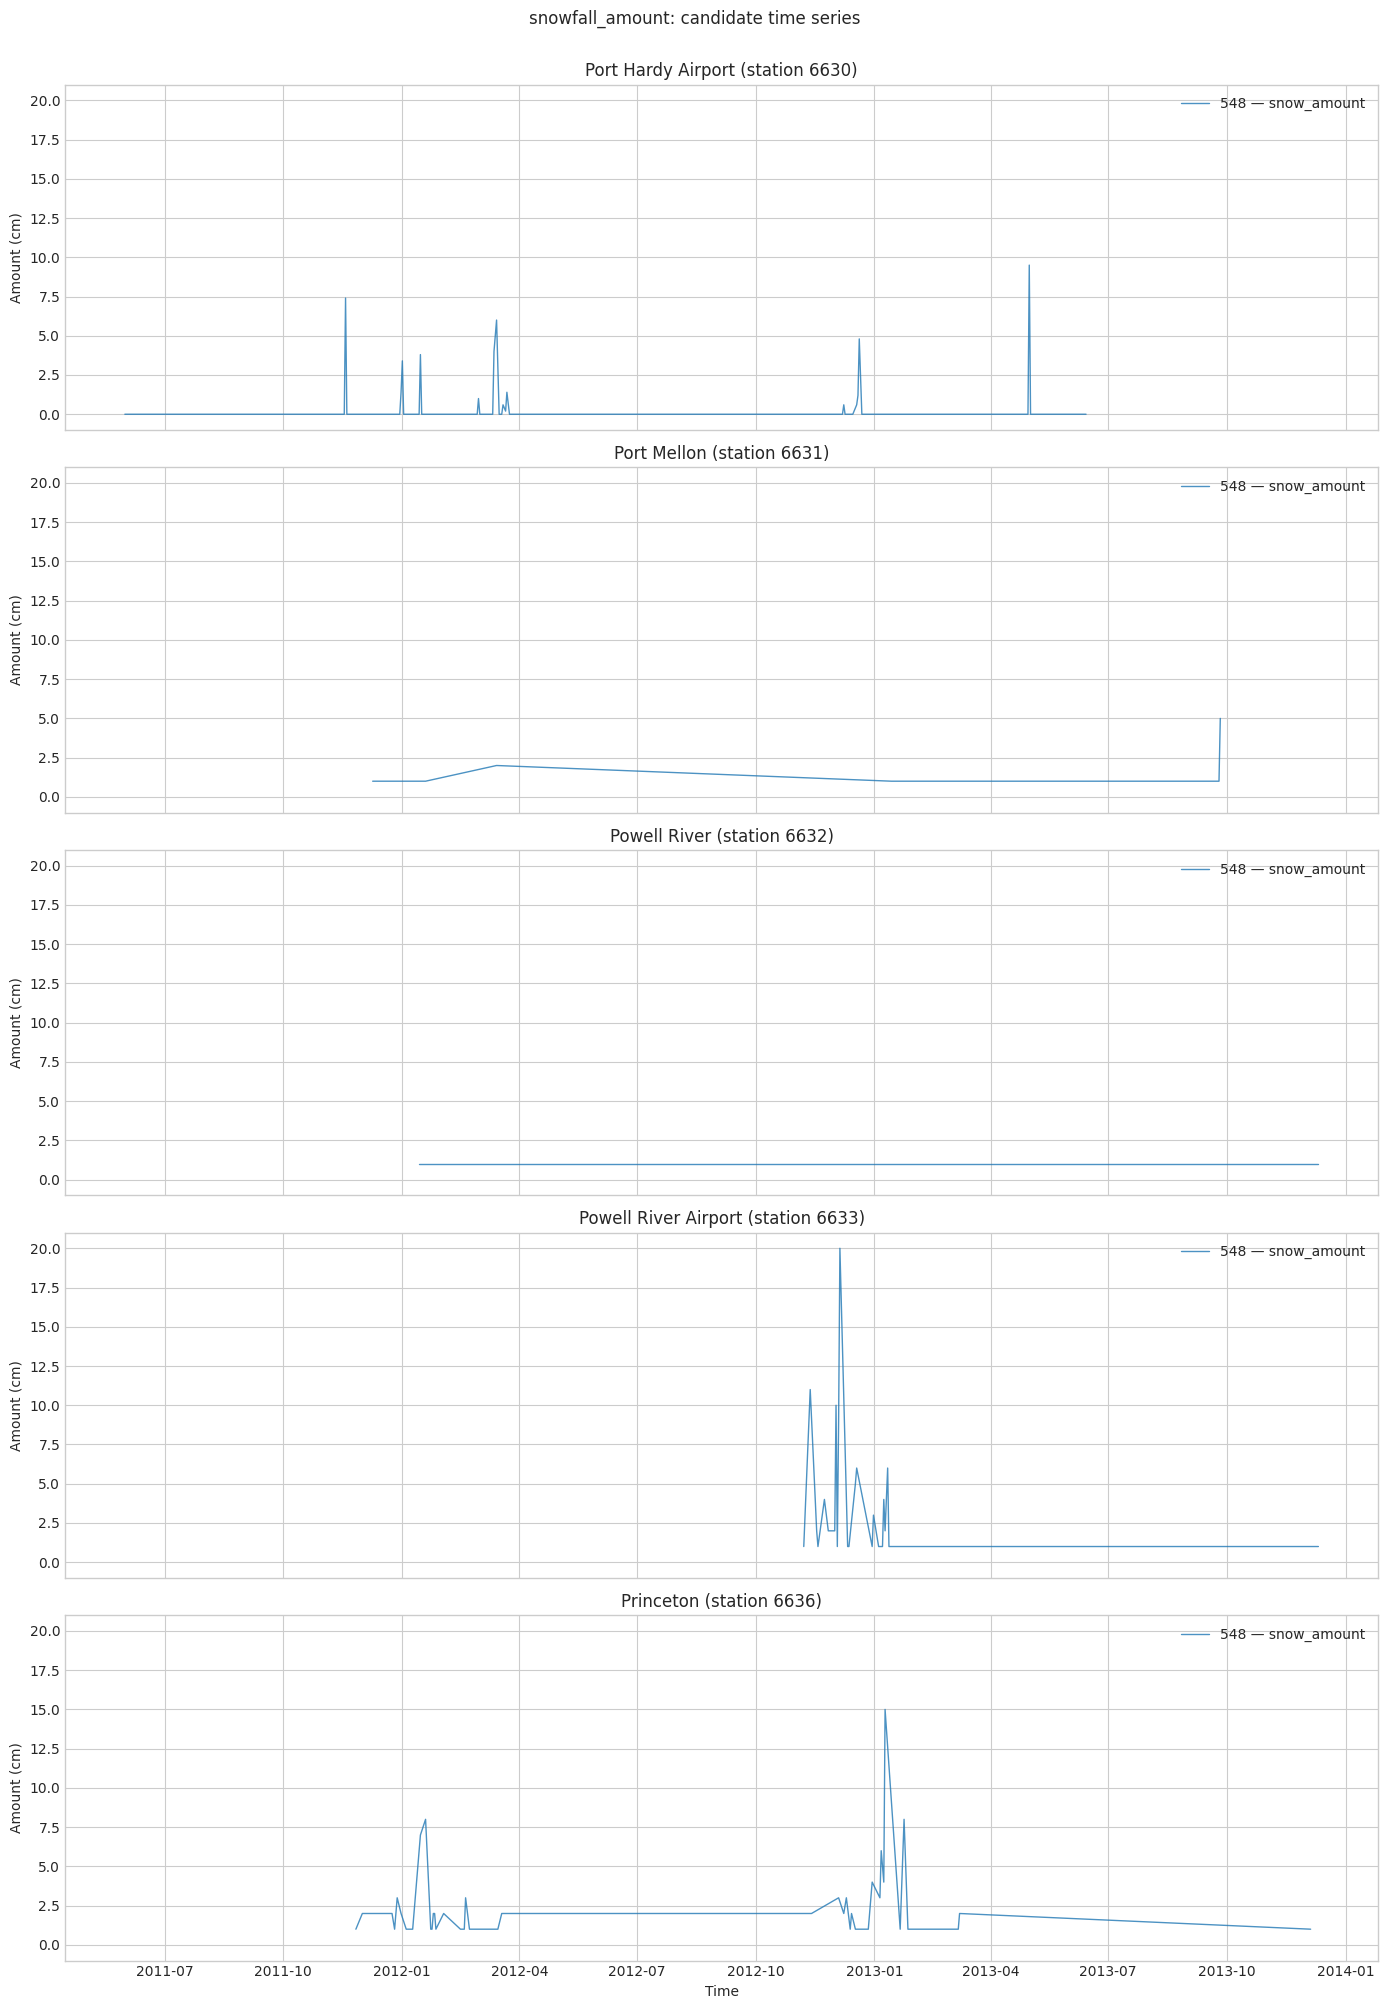

In [6]:
unit_labels = {
    'celsius': 'Temperature (°C)', 'mm': 'Amount (mm)', 'cm': 'Amount (cm)'}
ylabel = unit_labels[CANONICAL_RULES[CANONICAL_VARIABLE].unit]
plot_data = clean_data
if PLOT_VARIABLE_IDS is not None:
    plot_data = clean_data[
        clean_data['vars_id'].isin(PLOT_VARIABLE_IDS)
    ].copy()
    if plot_data.empty:
        raise ValueError(
            'None of PLOT_VARIABLE_IDS has valid data for the selected stations.'
        )

stations = list(plot_data.groupby('station_id'))

fig, axes = plt.subplots(len(stations), 1, figsize=(14, 4 * len(stations)),
                         sharex=True, sharey=True, squeeze=False)
for ax, (station_id, station_data) in zip(axes.ravel(), stations):
    for (vars_id, variable_name), variable_data in station_data.groupby(
        ['vars_id', 'net_var_name']
    ):
        ax.plot(variable_data['obs_time'], variable_data['datum'],
                linewidth=1, alpha=0.8,
                label=f'{vars_id} — {variable_name}')
    ax.set_title(
        f"{station_data['station_name'].iloc[0]} (station {station_id})")
    ax.set_ylabel(ylabel)
    ax.legend()
axes[-1, 0].set_xlabel('Time')
fig.suptitle(f'{CANONICAL_VARIABLE}: candidate time series', y=1.002)
plt.tight_layout()
time_series_path = FIGURE_DIR / (
    f'network_{NETWORK_ID}_{CANONICAL_VARIABLE}_time_series.png'
)
fig.savefig(time_series_path, dpi=150, bbox_inches='tight')
print(f'Saved: {time_series_path}')
plt.show()

## 5. Empirical cumulative distributions

Precipitation and snowfall ECDFs use positive values only and a logarithmic amount axis. Temperature and snow-depth ECDFs retain all plausible values.

Saved: /workspaces/crmprtd/Quanlity_Control/pipeline/network_19/variable_mapping_figures/network_19_snowfall_amount_cdf.png


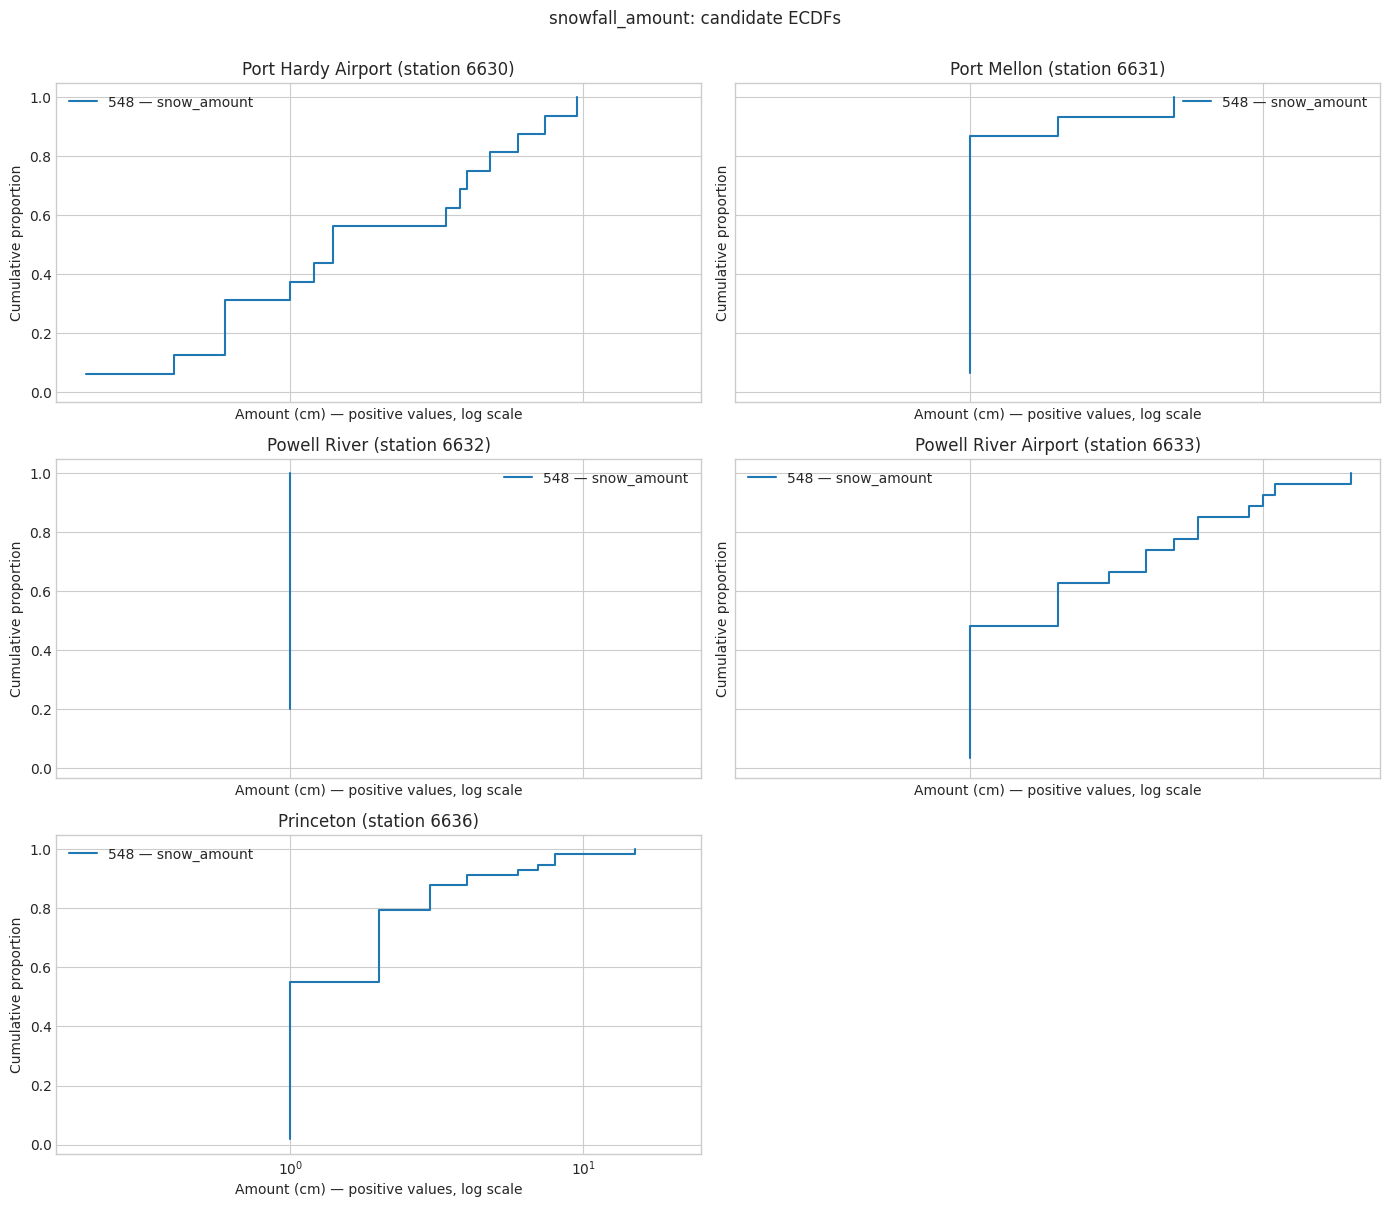

In [7]:
positive_only = CANONICAL_VARIABLE in {
    'precipitation_amount', 'snowfall_amount'}
log_x = positive_only
ncols = 2
nrows = int(np.ceil(len(stations) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                         sharex=True, sharey=True, squeeze=False)
axes = axes.ravel()

for ax, (station_id, station_data) in zip(axes, stations):
    for (vars_id, variable_name), variable_data in station_data.groupby(
        ['vars_id', 'net_var_name']
    ):
        values = variable_data['datum'].dropna()
        if positive_only:
            values = values[values > 0]
        values = np.sort(values.to_numpy())
        if len(values):
            cumulative = np.arange(1, len(values) + 1) / len(values)
            ax.step(values, cumulative, where='post',
                    label=f'{vars_id} — {variable_name}')
    if log_x:
        ax.set_xscale('log')
    ax.set_title(
        f"{station_data['station_name'].iloc[0]} (station {station_id})")
    ax.set_xlabel(
        ylabel + (' — positive values, log scale' if positive_only else ''))
    ax.set_ylabel('Cumulative proportion')
    ax.legend()

for ax in axes[len(stations):]:
    ax.set_visible(False)
fig.suptitle(f'{CANONICAL_VARIABLE}: candidate ECDFs', y=1.002)
plt.tight_layout()
cdf_path = FIGURE_DIR / (
    f'network_{NETWORK_ID}_{CANONICAL_VARIABLE}_cdf.png'
)
fig.savefig(cdf_path, dpi=150, bbox_inches='tight')
print(f'Saved: {cdf_path}')
plt.show()

In [8]:
# Record the reviewed selection and merge policy; do not combine data here.
import json
FINAL_SOURCE_IDS = [548]
FINAL_RULE_PATH = (
    OUTPUT_DIR / f'1.net{NETWORK_ID}_final_variable_rules.csv'
)

if not FINAL_SOURCE_IDS:
    print(
        f'No rule saved for {CANONICAL_VARIABLE}: review the figures, '
        'fill FINAL_SOURCE_IDS in the setup cell, then rerun this cell.'
    )
else:
    unknown_ids = set(FINAL_SOURCE_IDS) - set(candidate_ids)
    if unknown_ids:
        raise ValueError(
            f'FINAL_SOURCE_IDS are not candidates for '
            f'{CANONICAL_VARIABLE}: {sorted(unknown_ids)}'
        )

    # Infer cadence from the median positive interval at each station.
    selected_observations = observations[
        observations['vars_id'].isin(FINAL_SOURCE_IDS)
    ].copy()
    selected_observations['obs_time'] = pd.to_datetime(
        selected_observations['obs_time']
    )

    frequency_rows = []
    for source_id in FINAL_SOURCE_IDS:
        source_times = (
            selected_observations.loc[
                selected_observations['vars_id'] == source_id,
                ['station_id', 'obs_time'],
            ]
            .drop_duplicates()
            .sort_values(['station_id', 'obs_time'])
        )
        intervals = (
            source_times.groupby('station_id')['obs_time']
            .diff()
            .dt.total_seconds()
            .div(3600)
        )
        intervals = intervals[intervals > 0]
        if intervals.empty:
            raise ValueError(
                f'Cannot infer observation frequency for vars_id {source_id}'
            )

        median_interval_hours = float(intervals.median())
        if 0.75 <= median_interval_hours <= 1.25:
            frequency = 'hourly'
        elif 20 <= median_interval_hours <= 28:
            frequency = 'daily'
        else:
            frequency = f'irregular_{median_interval_hours:g}_hours'

        frequency_rows.append({
            'vars_id': source_id,
            'median_interval_hours': median_interval_hours,
            'time_match': frequency,
        })

    frequency_summary = pd.DataFrame(frequency_rows)
    unique_frequencies = frequency_summary['time_match'].unique()
    if len(unique_frequencies) == 1:
        time_match = unique_frequencies[0]
    else:
        time_match = 'mixed:' + ','.join(
            f"{row.vars_id}={row.time_match}"
            for row in frequency_summary.itertuples()
        )
    display(frequency_summary)

    final_rule = pd.DataFrame([{
        'network_id': NETWORK_ID,
        'canonical_variable': CANONICAL_VARIABLE,
        'source_vars_ids': json.dumps(FINAL_SOURCE_IDS),
        'time_match': time_match,
        'overlap_method': 'mean',
        'single_source_method': 'use_available',
    }])

    if FINAL_RULE_PATH.exists():
        saved_rules = pd.read_csv(FINAL_RULE_PATH)
        same_mapping = (
            (saved_rules['network_id'] == NETWORK_ID)
            & (saved_rules['canonical_variable'] == CANONICAL_VARIABLE)
        )
        saved_rules = saved_rules.loc[~same_mapping]
        final_rules = pd.concat(
            [saved_rules, final_rule], ignore_index=True
        )
    else:
        final_rules = final_rule

    final_rules = final_rules.sort_values(
        ['network_id', 'canonical_variable']
    ).reset_index(drop=True)
    final_rules.to_csv(FINAL_RULE_PATH, index=False)
    print(f'Saved rule: {NETWORK_ID} / {CANONICAL_VARIABLE}')
    display(final_rules)

,vars_id,median_interval_hours,time_match
0,548,24.0,daily


Saved rule: 19 / snowfall_amount


,network_id,canonical_variable,source_vars_ids,time_match,overlap_method,single_source_method
0,19,air_temperature,[542],hourly,mean,use_available
1,19,daily_max_temperature,[544],daily,mean,use_available
2,19,daily_min_temperature,[545],daily,mean,use_available
3,19,precipitation_amount,[546],daily,mean,use_available
4,19,snowfall_amount,[548],daily,mean,use_available
